In [ ]:
from google.colab import files

uploaded = files.upload()

Saving diabetes.csv to diabetes (1).csv


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
df = pd.read_csv("diabetes.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [ ]:
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

In [ ]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Input columns:")
print(X.columns)

print("\nTarget:")
print(y.name)

Input columns:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

Target:
Outcome


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LogisticRegression()

model.fit(X_train_scaled, y_train)

print("Model training completed!")

Model training completed!


In [ ]:
y_pred = model.predict(X_test_scaled)

print("Predictions:")
print(y_pred)

Predictions:
[1 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 1 0 1 0 0 1 0 1 1 0 1 0 0 0 0 0 0 1 1 0 0
 0 1 1 0 0 0 0 0 0 0 0 1 1 1 1 0 0 1 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 1 1 0 0 0 0 0 1 0 1 0 1 0 0
 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1
 1 0 0 0 1 0]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 0.7142857142857143
Accuracy Percentage: 71.42857142857143 %


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[82 18]
 [26 28]]


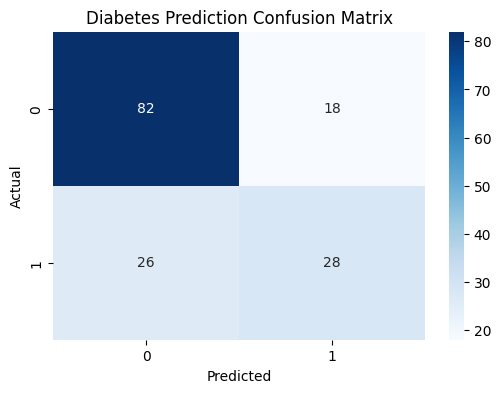

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Diabetes Prediction Confusion Matrix")

plt.show()

In [ ]:
patient = np.array([[2, 120, 70, 30, 100, 30.5, 0.5, 35]])

patient_scaled = scaler.transform(patient)

prediction = model.predict(patient_scaled)

if prediction[0] == 1:
    print("Prediction: Diabetic")
else:
    print("Prediction: Not Diabetic")

Prediction: Not Diabetic


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
import joblib

joblib.dump(model, "diabetes_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [ ]:
from google.colab import files

files.download("diabetes_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 61.2 MB/s eta 0:00:00


In [ ]:
import streamlit

print("Streamlit installed successfully!")

Streamlit installed successfully!


In [ ]:
%%writefile app.py

import streamlit as st
import numpy as np
import joblib

# Load model and scaler
model = joblib.load("diabetes_model.pkl")
scaler = joblib.load("scaler.pkl")

st.set_page_config(
    page_title="Diabetes Prediction",
    page_icon="🩺"
)

st.title("🩺 Diabetes Prediction System")

st.write("Enter the patient's information below.")

pregnancies = st.number_input(
    "Pregnancies",
    min_value=0,
    max_value=20,
    value=1
)

glucose = st.number_input(
    "Glucose",
    min_value=0,
    max_value=300,
    value=120
)

blood_pressure = st.number_input(
    "Blood Pressure",
    min_value=0,
    max_value=200,
    value=70
)

skin_thickness = st.number_input(
    "Skin Thickness",
    min_value=0,
    max_value=100,
    value=20
)

insulin = st.number_input(
    "Insulin",
    min_value=0,
    max_value=900,
    value=100
)

bmi = st.number_input(
    "BMI",
    min_value=0.0,
    max_value=70.0,
    value=25.0
)

diabetes_pedigree = st.number_input(
    "Diabetes Pedigree Function",
    min_value=0.0,
    max_value=3.0,
    value=0.5
)

age = st.number_input(
    "Age",
    min_value=1,
    max_value=120,
    value=30
)

if st.button("Predict"):

    patient_data = np.array([[
        pregnancies,
        glucose,
        blood_pressure,
        skin_thickness,
        insulin,
        bmi,
        diabetes_pedigree,
        age
    ]])

    patient_scaled = scaler.transform(patient_data)

    prediction = model.predict(patient_scaled)

    probability = model.predict_proba(patient_scaled)[0][1]

    if prediction[0] == 1:
        st.error("⚠️ Prediction: Diabetic")
    else:
        st.success("✅ Prediction: Not Diabetic")

    st.write(
        "Diabetes probability:",
        round(probability * 100, 2),
        "%"
    )

Writing app.py


In [ ]:
import os

print(os.listdir())

['.config', 'diabetes (1).csv', 'scaler.pkl', 'app.py', 'diabetes.csv', 'diabetes_model.pkl', 'sample_data']


In [ ]:
!streamlit run app.py &>/content/log.txt &

In [ ]:
!cat /content/log.txt



2026-09-20 18:36:15.753 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.75.123.249:8501



In [ ]:
!pip install pyngrok -q

In [ ]:
!ngrok config add-authtoken 3JbV5ezL56JGEpjmxbzgCuA0YKV_25enc3e1Hw8LpHx9SKUbo

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print("Your app is here:")
print(public_url)

Your app is here:
NgrokTunnel: "https://blooming-unselect-dubbed.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
%%writefile app.py

import streamlit as st
import numpy as np
import joblib

# Load trained model
model = joblib.load("diabetes_model.pkl")
scaler = joblib.load("scaler.pkl")


# -----------------------------
# Page Configuration
# -----------------------------

st.set_page_config(
    page_title="Diabetes Prediction System",
    page_icon="🩺",
    layout="centered"
)


# -----------------------------
# Title
# -----------------------------

st.title("🩺 Diabetes Prediction System")

st.write(
    "Enter the patient's medical information below "
    "to predict the likelihood of diabetes."
)

st.divider()


# -----------------------------
# Patient Information
# -----------------------------

st.subheader("Patient Information")


col1, col2 = st.columns(2)

with col1:

    pregnancies = st.number_input(
        "Pregnancies",
        min_value=0,
        max_value=20,
        value=1
    )

    glucose = st.number_input(
        "Glucose",
        min_value=0,
        max_value=300,
        value=120
    )

    blood_pressure = st.number_input(
        "Blood Pressure",
        min_value=0,
        max_value=200,
        value=70
    )

    skin_thickness = st.number_input(
        "Skin Thickness",
        min_value=0,
        max_value=100,
        value=20
    )


with col2:

    insulin = st.number_input(
        "Insulin",
        min_value=0,
        max_value=900,
        value=100
    )

    bmi = st.number_input(
        "BMI",
        min_value=0.0,
        max_value=70.0,
        value=25.0
    )

    diabetes_pedigree = st.number_input(
        "Diabetes Pedigree Function",
        min_value=0.0,
        max_value=3.0,
        value=0.5
    )

    age = st.number_input(
        "Age",
        min_value=1,
        max_value=120,
        value=30
    )


st.divider()


# -----------------------------
# Prediction
# -----------------------------

if st.button("🔍 Predict Diabetes", use_container_width=True):

    # Create patient data
    patient_data = np.array([[
        pregnancies,
        glucose,
        blood_pressure,
        skin_thickness,
        insulin,
        bmi,
        diabetes_pedigree,
        age
    ]])

    # Scale data
    patient_scaled = scaler.transform(patient_data)

    # Prediction
    prediction = model.predict(patient_scaled)

    # Probability
    probability = model.predict_proba(patient_scaled)[0][1]

    st.subheader("Prediction Result")

    if prediction[0] == 1:

        st.error("⚠️ The model predicts: Diabetes")

    else:

        st.success("✅ The model predicts: No Diabetes")

    st.write(
        f"Estimated diabetes probability: **{probability * 100:.2f}%**"
    )

    st.progress(float(probability))


st.divider()


# -----------------------------
# About the Project
# -----------------------------

st.subheader("About This Project")

st.write(
    """
    This project uses Machine Learning to predict the likelihood
    of diabetes based on patient information.

    The model was trained using the Pima Indians Diabetes dataset
    and uses Logistic Regression for binary classification.

    **Important:** This application is for educational purposes
    and should not be used as a medical diagnosis.
    """
)

Overwriting app.py


In [ ]:
!pkill -f streamlit

In [ ]:
!streamlit run app.py &>/content/log.txt &

In [ ]:
!cat /content/log.txt



2026-09-20 18:43:18.275 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.75.123.249:8501



In [ ]:
from pyngrok import ngrok

ngrok.kill()

public_url = ngrok.connect(8501)

print("YOUR DIABETES APP:")
print(public_url)


YOUR DIABETES APP:
NgrokTunnel: "https://blooming-unselect-dubbed.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions
y_pred = model.predict(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("====================================")
print("       MODEL PERFORMANCE")
print("====================================")

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Accuracy Percentage: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

       MODEL PERFORMANCE

Accuracy: 0.7143
Accuracy Percentage: 71.43%

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154


Confusion Matrix:
[[82 18]
 [26 28]]
